In [1]:
import numpy as np
import pickle
from environment import State, ManipulatorEnv
import rtt_planning_lib
import matplotlib.pyplot as plt

In [2]:
with open("data.pickle", "rb") as f:
    data = pickle.load(f)

start_state = State(np.array(data["start_state"]))
goal_state = State(np.array(data["goal_state"]))

env = ManipulatorEnv(
    obstacles=np.array(data["obstacles"]),
    initial_state=start_state,
    collision_threshold=data["collision_threshold"]
)

In [3]:
start_list = np.array(data["start_state"]).tolist()
goal_list = np.array(data["goal_state"]).tolist()
obstacles_list = np.array(data["obstacles"]).tolist()

In [4]:
print("rrt:")
print(dir(rtt_planning_lib))

rrt:
['RRT', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'py_list_to_vector1d', 'py_list_to_vector2d', 'state_to_angles_list']


In [5]:
# function to visualize a given state
def visualize_state(env, state, title="State"):
    env.state = state
    plt.figure(figsize=(6, 6))
    env.render(plt_show=False)
    plt.title(title)
    plt.show()

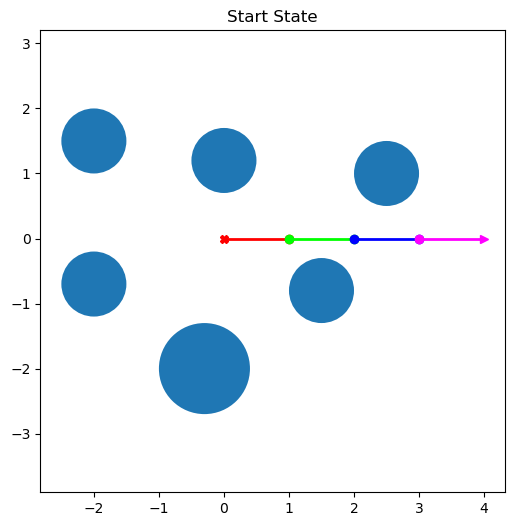

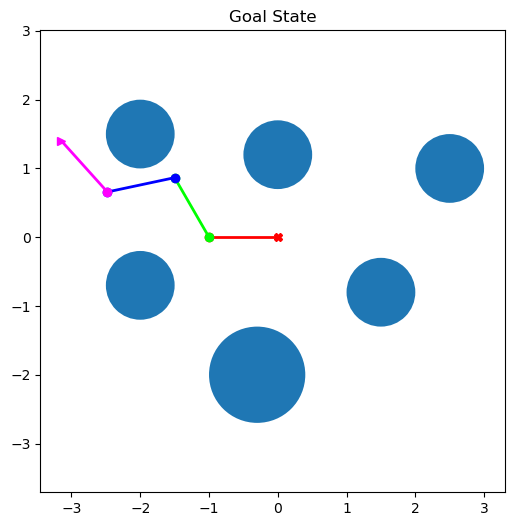

In [6]:
visualize_state(env, start_state, "Start State")
visualize_state(env, goal_state, "Goal State")

In [7]:
planner = rtt_planning_lib.RRT(obstacles_list)
planner.set_start_goal(start_list, goal_list)

RRT has been created


In [8]:
random_states = []
collisions_list = []
for i in range(4):
    angles = planner.sample()
    state = State(np.array(angles))
    while i % 2 == 0 and planner.check_collision(angles):
        angles = planner.sample()
        state = State(np.array(angles))
    while i % 2 != 0 and not planner.check_collision(angles):
        angles = planner.sample()
        state = State(np.array(angles))
    print(planner.check_collision(angles))
    random_states.append(state)

False
True
False
True



=== Random state 1 ===
Angles: [-180.  -60.   72.  -60.]
Collision: False


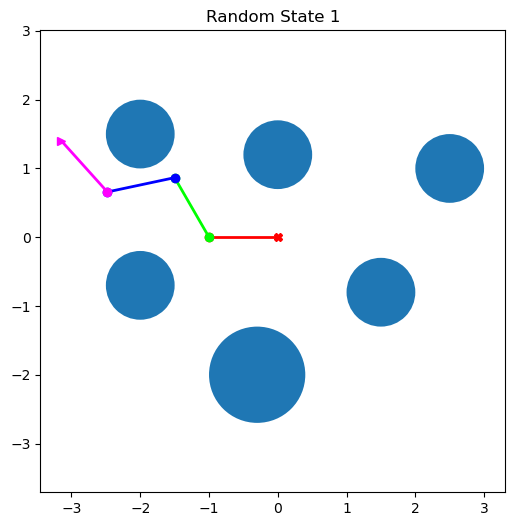


=== Random state 2 ===
Angles: [ 54.02041955 172.56233609 151.69651131 106.35146012]
Collision: True


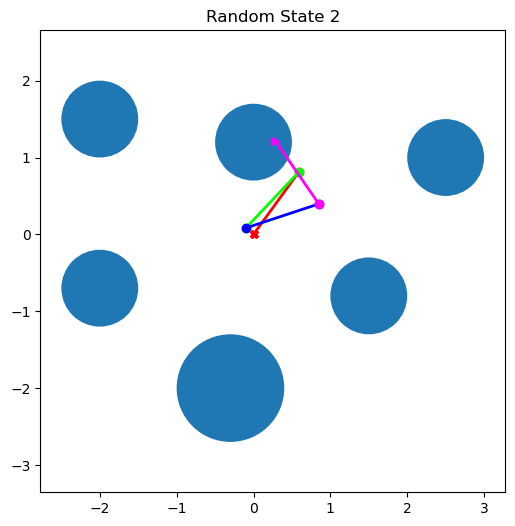


=== Random state 3 ===
Angles: [ -41.04198021 -144.72666312  -35.91527368  165.72886   ]
Collision: False


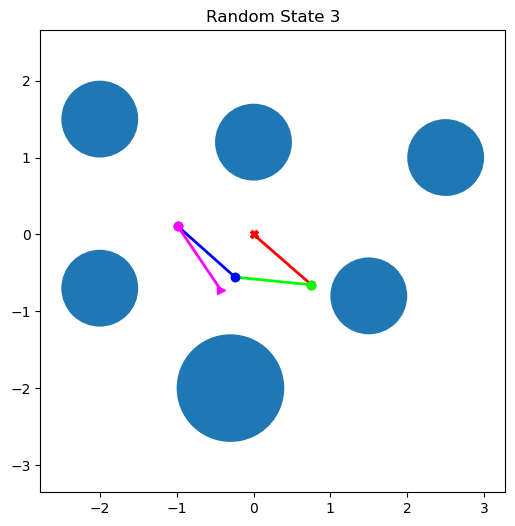


=== Random state 4 ===
Angles: [  93.29373182 -124.31374795  137.51484647  -17.72133919]
Collision: True


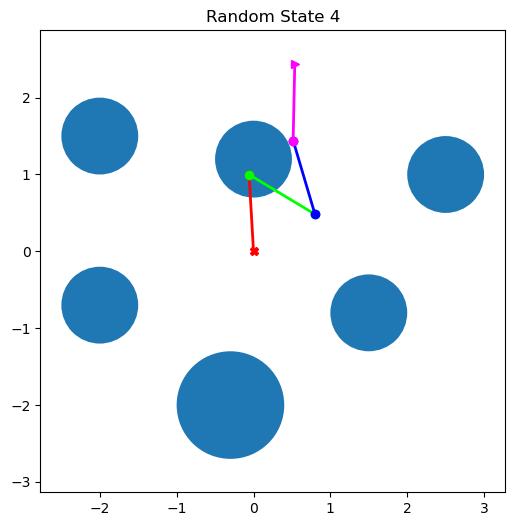

In [9]:
for i, st in enumerate(random_states, 1):
    print(f"\n=== Random state {i} ===")
    print("Angles:", st.angles)
    
    collision = env.check_collision(st)
    print("Collision:", collision)
    
    visualize_state(env, st, f"Random State {i}")


In [10]:
def visualize_states_single_plot(env, states, colors=None, title="All States"):
    """
    All states in the single canvas
    
    """
    plt.figure(figsize=(10, 10))
    original_state = env.state
    if colors is None:
        colors = plt.cm.rainbow(np.linspace(0, 1, len(states)))
    for i, state in enumerate(states):
        env.state = state
        joints = state.joints
        color = colors[i] if i < len(colors) else 'blue'
        for j in range(4):
            segment = joints[[j, j+1], :]
            alpha = 0.7 if i == len(states)-1 else 0.3 
            plt.plot(segment[:, 0], segment[:, 1], 'o-', 
                    color=color, alpha=alpha, linewidth=2)
    for obs in env._obstacles:
        plt.gca().add_patch(
            plt.Circle((obs[0], obs[1]), obs[2], fill=True, alpha=0.5))
    env.state = original_state
    
    plt.axis('equal')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

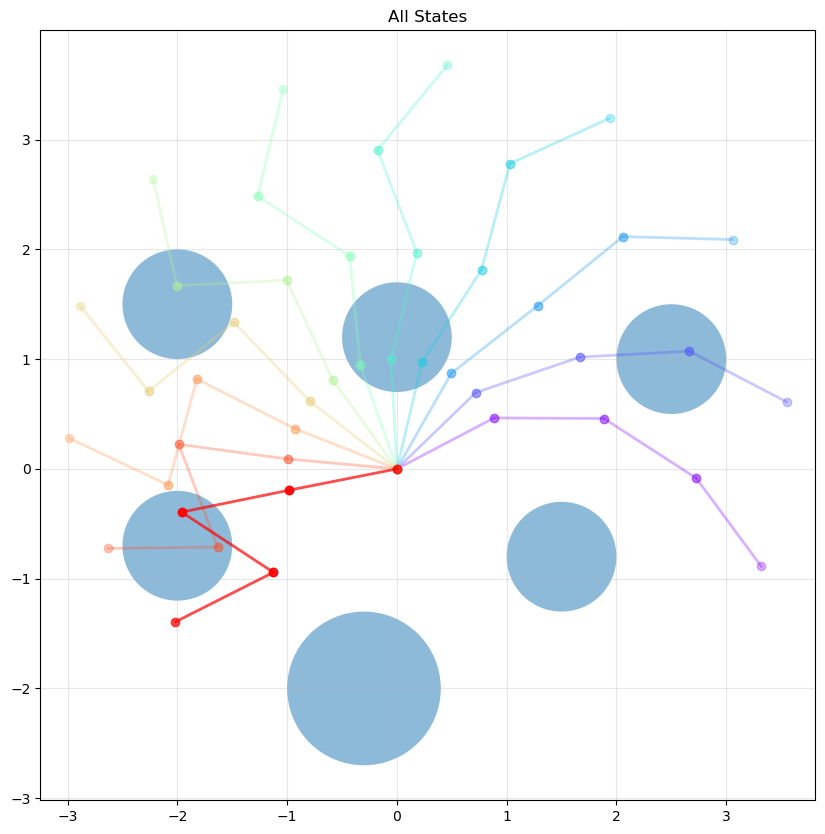

In [11]:
angles_list = planner.generate_states_btw(planner.sample(), planner.sample())
states_btw = []

for i, angles in enumerate(angles_list):
    state = State(np.array(angles))
    states_btw.append(state)
visualize_states_single_plot(env, states_btw)


Find the path!
ITER: 2250
Final size of path: 53


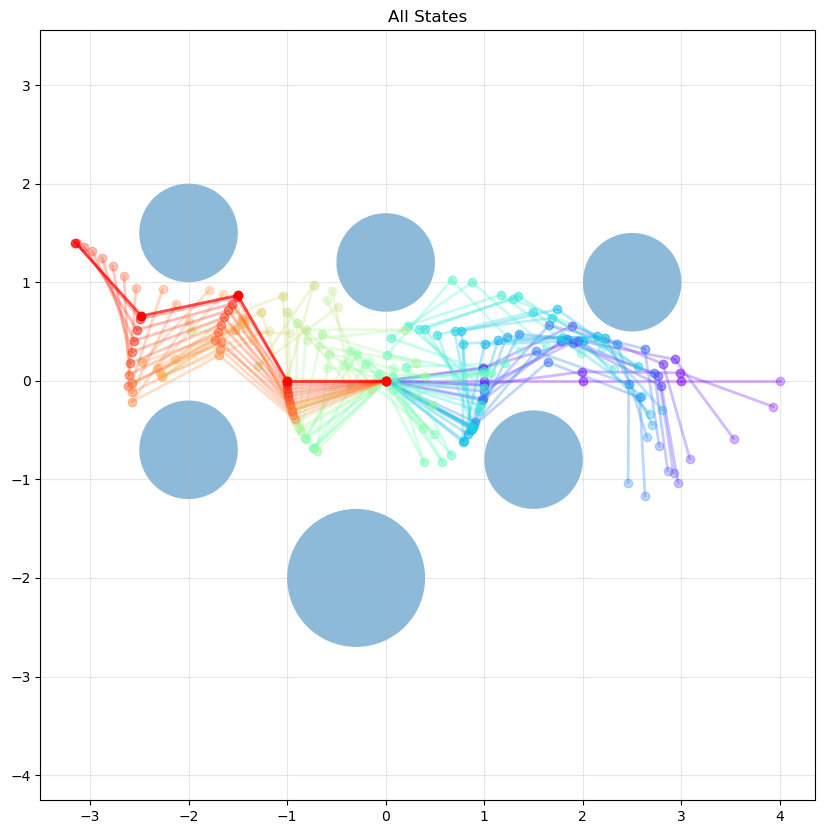

In [26]:
if planner.launch():
    plann_list = planner.get_plan()
    state_list = []
    for i, angles in enumerate(plann_list):
        state = State(np.array(angles))
        state_list.append(state)
    size = len(state_list)
    print(f"Final size of path: {size}")
    visualize_states_single_plot(env, state_list)
